## Подготовка среды

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as T
from torchvision import datasets, models

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("device:", device)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
device: cpu


In [3]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUNS_CSV_PATH = ARTIFACTS_DIR / "runs.csv"
BEST_MODEL_PATH = ARTIFACTS_DIR / "best_classifier.pt"
BEST_CONFIG_PATH = ARTIFACTS_DIR / "best_classifier_config.json"
BEST_CURVES_PATH = FIGURES_DIR / "classification_curves_best.png"
COMPARE_PATH = FIGURES_DIR / "classification_compare.png"
AUG_PREVIEW_PATH = FIGURES_DIR / "augmentations_preview.png"

## Загрузка и подготовка данных STL10

In [4]:
IMG_SIZE = 96
BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_CLASSES = 10

stl10_mean = (0.4467, 0.4398, 0.4066)
stl10_std = (0.2603, 0.2566, 0.2713)

train_transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=stl10_mean, std=stl10_std),
])

train_transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(IMG_SIZE, padding=8),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=stl10_mean, std=stl10_std),
])

eval_transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=stl10_mean, std=stl10_std),
])

resnet_weights = models.ResNet18_Weights.DEFAULT
resnet_preprocess = resnet_weights.transforms()

In [5]:
IMG_SIZE = 96
BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_CLASSES = 10

stl10_mean = (0.4467, 0.4398, 0.4066)
stl10_std = (0.2603, 0.2566, 0.2713)

train_transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=stl10_mean, std=stl10_std),
])

train_transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(IMG_SIZE, padding=8),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=stl10_mean, std=stl10_std),
])

eval_transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=stl10_mean, std=stl10_std),
])

resnet_weights = models.ResNet18_Weights.DEFAULT
resnet_preprocess = resnet_weights.transforms()

In [6]:
full_train_base = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=train_transform_base
)

full_train_aug = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=train_transform_aug
)

full_train_resnet = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=resnet_preprocess
)

test_base = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=False,
    transform=eval_transform_base
)

test_resnet = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=False,
    transform=resnet_preprocess
)

In [7]:
train_size = int(0.8 * len(full_train_base))
val_size = len(full_train_base) - train_size

generator = torch.Generator().manual_seed(SEED)
train_idx_subset, val_idx_subset = random_split(
    range(len(full_train_base)),
    [train_size, val_size],
    generator=generator
)

train_indices = train_idx_subset.indices
val_indices = val_idx_subset.indices

print("train:", len(train_indices))
print("val:", len(val_indices))
print("test:", len(test_base))

train: 4000
val: 1000
test: 8000


In [8]:
train_ds_c1 = Subset(full_train_base, train_indices)
val_ds_c1 = Subset(
    datasets.STL10(
        root=DATA_DIR,
        split="train",
        download=False,
        transform=eval_transform_base
    ),
    val_indices
)

train_ds_c2 = Subset(full_train_aug, train_indices)
val_ds_c2 = Subset(
    datasets.STL10(
        root=DATA_DIR,
        split="train",
        download=False,
        transform=eval_transform_base
    ),
    val_indices
)

train_ds_c3c4 = Subset(full_train_resnet, train_indices)
val_ds_c3c4 = Subset(
    datasets.STL10(
        root=DATA_DIR,
        split="train",
        download=False,
        transform=resnet_preprocess
    ),
    val_indices
)

test_ds_c1c2 = test_base
test_ds_c3c4 = test_resnet

In [9]:
train_loader_c1 = DataLoader(
    train_ds_c1,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader_c1 = DataLoader(
    val_ds_c1,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

train_loader_c2 = DataLoader(
    train_ds_c2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader_c2 = DataLoader(
    val_ds_c2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

train_loader_c3c4 = DataLoader(
    train_ds_c3c4,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader_c3c4 = DataLoader(
    val_ds_c3c4,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader_c1c2 = DataLoader(
    test_ds_c1c2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader_c3c4 = DataLoader(
    test_ds_c3c4,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

## Проверка данных и визуализация

In [10]:
x_batch, y_batch = next(iter(train_loader_c1))

print("x_batch.shape:", x_batch.shape)
print("y_batch.shape:", y_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)

x_batch.shape: torch.Size([64, 3, 96, 96])
y_batch.shape: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64


In [11]:
classes = full_train_base.classes
classes

['airplane',
 'bird',
 'car',
 'cat',
 'deer',
 'dog',
 'horse',
 'monkey',
 'ship',
 'truck']

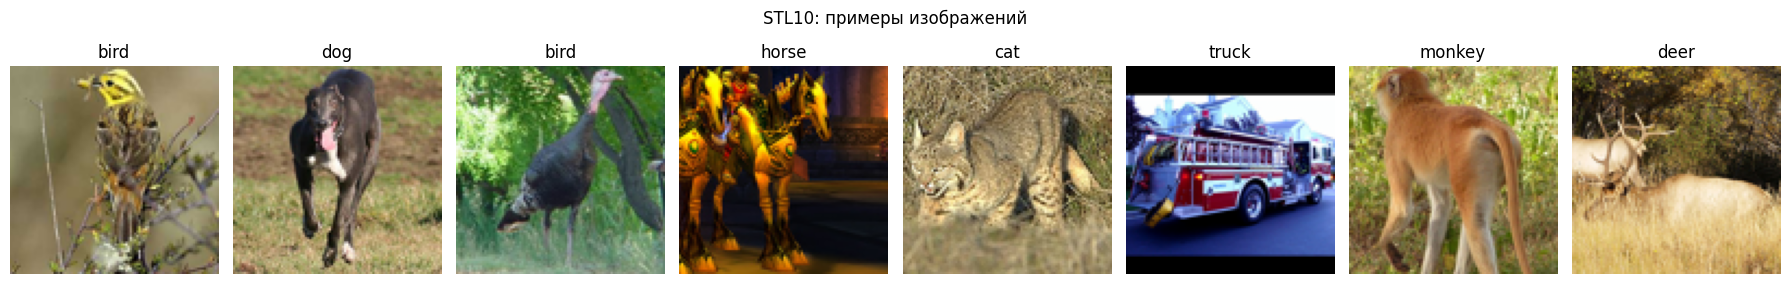

In [12]:
def denormalize_image(img_tensor, mean, std):
    mean = torch.tensor(mean, dtype=img_tensor.dtype, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, dtype=img_tensor.dtype, device=img_tensor.device).view(3, 1, 1)
    img_tensor = img_tensor * std + mean
    return img_tensor.clamp(0, 1)


def show_images(dataset, class_names=None, n=8, title="Примеры изображений"):
    fig, axes = plt.subplots(1, n, figsize=(18, 3))

    for i in range(n):
        img, label = dataset[i]

        img = denormalize_image(img, stl10_mean, stl10_std)
        img = img.permute(1, 2, 0).cpu().numpy()

        axes[i].imshow(img)
        axes[i].set_title(class_names[label] if class_names is not None else str(label))
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_images(full_train_base, class_names=classes, n=8, title="STL10: примеры изображений")

## Визуализация аугментаций

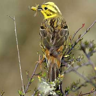

In [13]:
sample_pil = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=None
)[0][0]

sample_pil

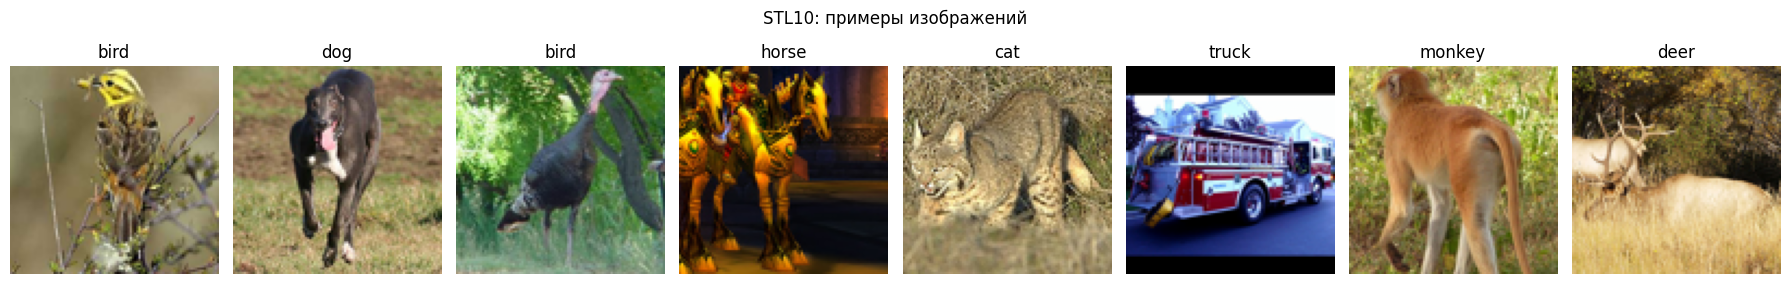

In [14]:
def denormalize_image(img_tensor, mean, std):
    mean = torch.tensor(mean, dtype=img_tensor.dtype, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, dtype=img_tensor.dtype, device=img_tensor.device).view(3, 1, 1)
    img_tensor = img_tensor * std + mean
    return img_tensor.clamp(0, 1)


def show_images(dataset, class_names=None, n=8, title="Примеры изображений"):
    fig, axes = plt.subplots(1, n, figsize=(18, 3))

    for i in range(n):
        img, label = dataset[i]
        img = denormalize_image(img, stl10_mean, stl10_std)
        img = img.permute(1, 2, 0).cpu().numpy()

        axes[i].imshow(img)
        axes[i].set_title(class_names[label] if class_names is not None else str(label))
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_images(full_train_base, class_names=classes, n=8, title="STL10: примеры изображений")

## Модели и функции обучения

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [16]:
def build_resnet18_head_only(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model


def build_resnet18_partial_finetune(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    for param in model.fc.parameters():
        param.requires_grad = True

    return model

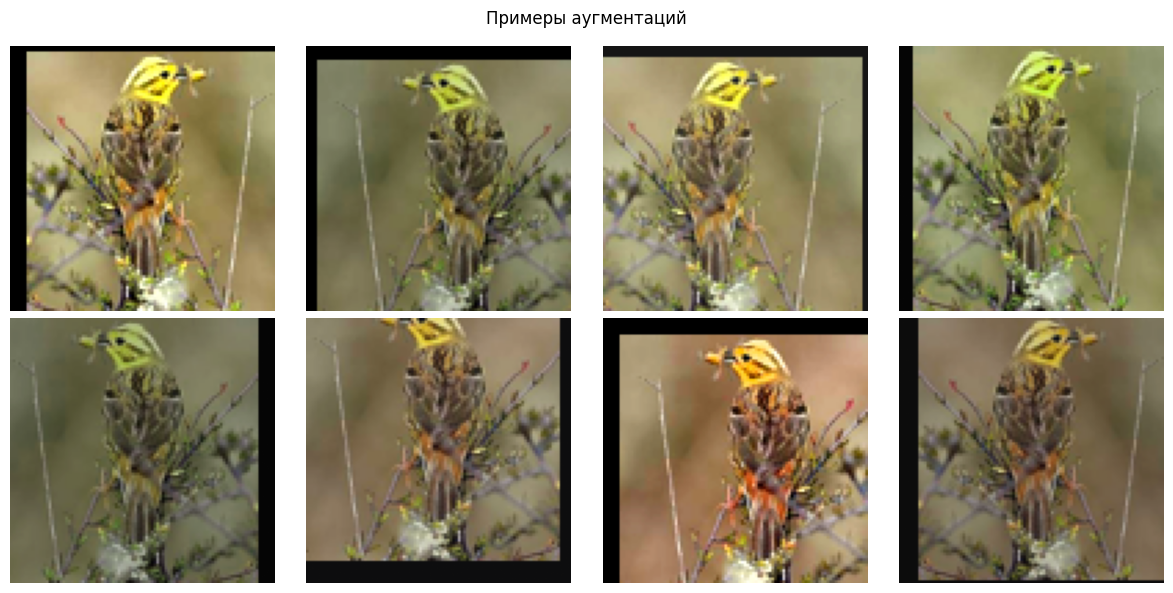

In [17]:
sample_pil = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=None
)[0][0]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.ravel():
    aug_img = train_transform_aug(sample_pil)
    aug_img = denormalize_image(aug_img, stl10_mean, stl10_std)
    aug_img = aug_img.permute(1, 2, 0).cpu().numpy()

    ax.imshow(aug_img)
    ax.axis("off")

plt.suptitle("Примеры аугментаций")
plt.tight_layout()
plt.savefig(AUG_PREVIEW_PATH, dpi=150, bbox_inches="tight")
plt.show()

In [18]:
def fit_classification_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=5
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = None
    best_val_acc = -1.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    return history, best_state, best_val_acc

## Эксперименты C1-C4

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        running_total += y.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        running_total += y.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [20]:
def fit_classification_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=5
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = None
    best_val_acc = -1.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    return history, best_state, best_val_acc

In [21]:
criterion = nn.CrossEntropyLoss()
runs = []
histories = {}
best_states = {}

In [22]:
model_c1 = SimpleCNN(num_classes=NUM_CLASSES).to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=1e-3)

history_c1, best_state_c1, best_val_acc_c1 = fit_classification_model(
    model=model_c1,
    train_loader=train_loader_c1,
    val_loader=val_loader_c1,
    criterion=criterion,
    optimizer=optimizer_c1,
    device=device,
    epochs=5
)

histories["C1"] = history_c1
best_states["C1"] = best_state_c1

runs.append({
    "experiment_id": "C1",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": "SimpleCNN without augmentations",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": 5,
    "best_val_accuracy": best_val_acc_c1,
    "test_accuracy": None,
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "notes": "simple-cnn-base"
})

Epoch 1/5 | train_loss=1.8186 | train_acc=0.3285 | val_loss=1.5776 | val_acc=0.4220
Epoch 2/5 | train_loss=1.3887 | train_acc=0.4760 | val_loss=1.2917 | val_acc=0.5150
Epoch 3/5 | train_loss=1.1702 | train_acc=0.5705 | val_loss=1.2377 | val_acc=0.5530
Epoch 4/5 | train_loss=0.9811 | train_acc=0.6395 | val_loss=1.3785 | val_acc=0.5090
Epoch 5/5 | train_loss=0.7421 | train_acc=0.7318 | val_loss=1.2721 | val_acc=0.5600


In [23]:
model_c2 = SimpleCNN(num_classes=NUM_CLASSES).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=1e-3)

history_c2, best_state_c2, best_val_acc_c2 = fit_classification_model(
    model=model_c2,
    train_loader=train_loader_c2,
    val_loader=val_loader_c2,
    criterion=criterion,
    optimizer=optimizer_c2,
    device=device,
    epochs=5
)

histories["C2"] = history_c2
best_states["C2"] = best_state_c2

runs.append({
    "experiment_id": "C2",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": "SimpleCNN with augmentations",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": 5,
    "best_val_accuracy": best_val_acc_c2,
    "test_accuracy": None,
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "notes": "simple-cnn-aug"
})

Epoch 1/5 | train_loss=2.0596 | train_acc=0.2200 | val_loss=1.6688 | val_acc=0.3800
Epoch 2/5 | train_loss=1.6815 | train_acc=0.3678 | val_loss=1.5287 | val_acc=0.4340
Epoch 3/5 | train_loss=1.5362 | train_acc=0.4145 | val_loss=1.4658 | val_acc=0.4360
Epoch 4/5 | train_loss=1.4478 | train_acc=0.4575 | val_loss=1.3840 | val_acc=0.4770
Epoch 5/5 | train_loss=1.3545 | train_acc=0.4953 | val_loss=1.2992 | val_acc=0.5010


In [24]:
model_c3 = build_resnet18_head_only(num_classes=NUM_CLASSES).to(device)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=1e-3)

history_c3, best_state_c3, best_val_acc_c3 = fit_classification_model(
    model=model_c3,
    train_loader=train_loader_c3c4,
    val_loader=val_loader_c3c4,
    criterion=criterion,
    optimizer=optimizer_c3,
    device=device,
    epochs=5
)

histories["C3"] = history_c3
best_states["C3"] = best_state_c3

runs.append({
    "experiment_id": "C3",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": "ResNet18 pretrained, head only",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": 5,
    "best_val_accuracy": best_val_acc_c3,
    "test_accuracy": None,
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "notes": "resnet18-head-only"
})

Epoch 1/5 | train_loss=1.0113 | train_acc=0.7595 | val_loss=0.4587 | val_acc=0.9060
Epoch 2/5 | train_loss=0.3693 | train_acc=0.9215 | val_loss=0.3177 | val_acc=0.9160
Epoch 3/5 | train_loss=0.2661 | train_acc=0.9435 | val_loss=0.2724 | val_acc=0.9270
Epoch 4/5 | train_loss=0.2285 | train_acc=0.9403 | val_loss=0.2424 | val_acc=0.9300
Epoch 5/5 | train_loss=0.1965 | train_acc=0.9477 | val_loss=0.2271 | val_acc=0.9230


In [25]:
model_c4 = build_resnet18_partial_finetune(num_classes=NUM_CLASSES).to(device)
optimizer_c4 = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=1e-4)

history_c4, best_state_c4, best_val_acc_c4 = fit_classification_model(
    model=model_c4,
    train_loader=train_loader_c3c4,
    val_loader=val_loader_c3c4,
    criterion=criterion,
    optimizer=optimizer_c4,
    device=device,
    epochs=5
)

histories["C4"] = history_c4
best_states["C4"] = best_state_c4

runs.append({
    "experiment_id": "C4",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": "ResNet18 pretrained, layer4 + fc finetune",
    "optimizer": "Adam",
    "lr": 1e-4,
    "epochs_trained": 5,
    "best_val_accuracy": best_val_acc_c4,
    "test_accuracy": None,
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "notes": "resnet18-finetune"
})

Epoch 1/5 | train_loss=0.6278 | train_acc=0.8330 | val_loss=0.2545 | val_acc=0.9240
Epoch 2/5 | train_loss=0.1203 | train_acc=0.9755 | val_loss=0.2090 | val_acc=0.9380
Epoch 3/5 | train_loss=0.0439 | train_acc=0.9975 | val_loss=0.1942 | val_acc=0.9430
Epoch 4/5 | train_loss=0.0189 | train_acc=1.0000 | val_loss=0.1970 | val_acc=0.9460
Epoch 5/5 | train_loss=0.0116 | train_acc=1.0000 | val_loss=0.1904 | val_acc=0.9460


In [26]:
classification_results = pd.DataFrame(runs)
classification_results[classification_results["task"] == "classification"][
    ["experiment_id", "model_summary", "best_val_accuracy"]
].sort_values("best_val_accuracy", ascending=False)

,experiment_id,model_summary,best_val_accuracy
3,C4,"ResNet18 pretrained, layer4 + fc finetune",0.946
2,C3,"ResNet18 pretrained, head only",0.930
0,C1,SimpleCNN without augmentations,0.560
1,C2,SimpleCNN with augmentations,0.501


## Выбор лучшей модели и оценка на test

In [27]:
classification_runs = [r for r in runs if r["task"] == "classification"]

best_cls_exp = max(
    classification_runs,
    key=lambda x: x["best_val_accuracy"]
)

best_experiment_id = best_cls_exp["experiment_id"]
best_cls_exp

{'experiment_id': 'C4',
 'task': 'classification',
 'dataset': 'STL10',
 'seed': 42,
 'model_summary': 'ResNet18 pretrained, layer4 + fc finetune',
 'optimizer': 'Adam',
 'lr': 0.0001,
 'epochs_trained': 5,
 'best_val_accuracy': 0.946,
 'test_accuracy': None,
 'precision': None,
 'recall': None,
 'mean_iou': None,
 'notes': 'resnet18-finetune'}

In [28]:
if best_experiment_id == "C1":
    best_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
    best_model.load_state_dict(best_states["C1"])
    test_loader_best = test_loader_c1c2
    best_architecture = "SimpleCNN"
    best_train_transform = "ToTensor() + Normalize(mean=stl10_mean, std=stl10_std)"
    best_val_transform = "ToTensor() + Normalize(mean=stl10_mean, std=stl10_std)"
    best_augmentation = "No augmentations"
    best_optimizer = "Adam"
    best_lr = 1e-3

elif best_experiment_id == "C2":
    best_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
    best_model.load_state_dict(best_states["C2"])
    test_loader_best = test_loader_c1c2
    best_architecture = "SimpleCNN"
    best_train_transform = (
        "RandomHorizontalFlip(p=0.5) + "
        "RandomCrop(96, padding=8) + "
        "ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05) + "
        "ToTensor() + Normalize(mean=stl10_mean, std=stl10_std)"
    )
    best_val_transform = "ToTensor() + Normalize(mean=stl10_mean, std=stl10_std)"
    best_augmentation = "HorizontalFlip + RandomCrop + ColorJitter"
    best_optimizer = "Adam"
    best_lr = 1e-3

elif best_experiment_id == "C3":
    best_model = build_resnet18_head_only(num_classes=NUM_CLASSES).to(device)
    best_model.load_state_dict(best_states["C3"])
    test_loader_best = test_loader_c3c4
    best_architecture = "ResNet18 pretrained, head-only"
    best_train_transform = "ResNet18_Weights.DEFAULT.transforms()"
    best_val_transform = "ResNet18_Weights.DEFAULT.transforms()"
    best_augmentation = "Pretrained ResNet preprocessing"
    best_optimizer = "Adam"
    best_lr = 1e-3

else:
    best_model = build_resnet18_partial_finetune(num_classes=NUM_CLASSES).to(device)
    best_model.load_state_dict(best_states["C4"])
    test_loader_best = test_loader_c3c4
    best_architecture = "ResNet18 pretrained, layer4 + fc fine-tuning"
    best_train_transform = "ResNet18_Weights.DEFAULT.transforms()"
    best_val_transform = "ResNet18_Weights.DEFAULT.transforms()"
    best_augmentation = "Pretrained ResNet preprocessing"
    best_optimizer = "Adam"
    best_lr = 1e-4

print("Лучшая модель:", best_experiment_id)
print("Архитектура:", best_architecture)

Лучшая модель: C4
Архитектура: ResNet18 pretrained, layer4 + fc fine-tuning


In [29]:
test_loss, test_acc = evaluate(best_model, test_loader_best, criterion, device)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.16457853688299656
Test accuracy: 0.947875


In [30]:
for r in runs:
    if r["task"] == "classification" and r["experiment_id"] == best_experiment_id:
        r["test_accuracy"] = test_acc

pd.DataFrame([r for r in runs if r["task"] == "classification"])

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN without augmentations,Adam,0.0010,5,0.560,NaN,None,None,None,simple-cnn-base
1,C2,classification,STL10,42,SimpleCNN with augmentations,Adam,0.0010,5,0.501,NaN,None,None,None,simple-cnn-aug
2,C3,classification,STL10,42,"ResNet18 pretrained, head only",Adam,0.0010,5,0.930,NaN,None,None,None,resnet18-head-only
3,C4,classification,STL10,42,"ResNet18 pretrained, layer4 + fc finetune",Adam,0.0001,5,0.946,0.947875,None,None,None,resnet18-finetune


In [31]:
torch.save(best_model.state_dict(), BEST_MODEL_PATH)

best_config = {
    "dataset": "STL10",
    "seed": SEED,
    "best_experiment_id": best_experiment_id,
    "architecture": best_architecture,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "criterion": "CrossEntropyLoss",
    "optimizer": best_optimizer,
    "learning_rate": best_lr,
    "epochs": 5,
    "train_transform": best_train_transform,
    "val_transform": best_val_transform,
    "augmentation": best_augmentation,
    "resnet_preprocess": "ResNet18_Weights.DEFAULT.transforms()" if best_experiment_id in ["C3", "C4"] else None,
    "normalization": {
        "mean": list(stl10_mean),
        "std": list(stl10_std),
    },
    "test_accuracy": test_acc,
}

with open(BEST_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

print("saved:", BEST_MODEL_PATH)
print("saved:", BEST_CONFIG_PATH)

saved: artifacts\best_classifier.pt
saved: artifacts\best_classifier_config.json


## Сохранение графиков и runs.csv

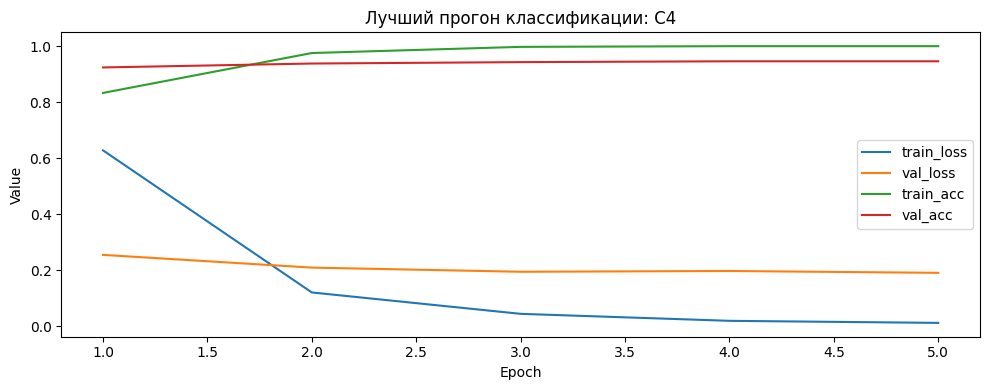

In [32]:
best_history = histories[best_experiment_id]
epochs_range = range(1, len(best_history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, best_history["train_loss"], label="train_loss")
plt.plot(epochs_range, best_history["val_loss"], label="val_loss")
plt.plot(epochs_range, best_history["train_acc"], label="train_acc")
plt.plot(epochs_range, best_history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title(f"Лучший прогон классификации: {best_experiment_id}")
plt.legend()
plt.tight_layout()
plt.savefig(BEST_CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()

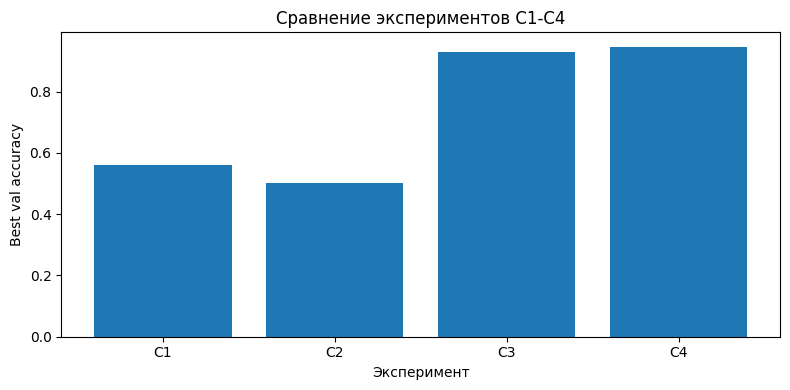

In [33]:
cls_df = pd.DataFrame([r for r in runs if r["task"] == "classification"])

plt.figure(figsize=(8, 4))
plt.bar(cls_df["experiment_id"], cls_df["best_val_accuracy"])
plt.xlabel("Эксперимент")
plt.ylabel("Best val accuracy")
plt.title("Сравнение экспериментов C1-C4")
plt.tight_layout()
plt.savefig(COMPARE_PATH, dpi=150, bbox_inches="tight")
plt.show()

In [34]:
runs_df = pd.DataFrame(runs)
runs_df.to_csv(RUNS_CSV_PATH, index=False)
runs_df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN without augmentations,Adam,0.0010,5,0.560,NaN,None,None,None,simple-cnn-base
1,C2,classification,STL10,42,SimpleCNN with augmentations,Adam,0.0010,5,0.501,NaN,None,None,None,simple-cnn-aug
2,C3,classification,STL10,42,"ResNet18 pretrained, head only",Adam,0.0010,5,0.930,NaN,None,None,None,resnet18-head-only
3,C4,classification,STL10,42,"ResNet18 pretrained, layer4 + fc finetune",Adam,0.0001,5,0.946,0.947875,None,None,None,resnet18-finetune


In [35]:
print("runs.csv:", RUNS_CSV_PATH.exists())
print("best_classifier.pt:", BEST_MODEL_PATH.exists())
print("best_classifier_config.json:", BEST_CONFIG_PATH.exists())
print("classification_curves_best.png:", BEST_CURVES_PATH.exists())
print("classification_compare.png:", COMPARE_PATH.exists())
print("augmentations_preview.png:", AUG_PREVIEW_PATH.exists())

runs.csv: True
best_classifier.pt: True
best_classifier_config.json: True
classification_curves_best.png: True
classification_compare.png: True
augmentations_preview.png: True


## Загрузка и подготовка данных OxfordIIITPet

In [36]:
pet_img_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

pet_mask_resize = T.Resize((224, 224), interpolation=T.InterpolationMode.NEAREST)

In [37]:
class OxfordPetSegmentationBinary(torch.utils.data.Dataset):
    def __init__(self, root, split="trainval"):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        image = pet_img_transform(image)
        mask = pet_mask_resize(mask)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)

        # 1 = pet, 2 = background, 3 = border
        binary_mask = (mask == 1).long()

        return image, binary_mask

In [38]:
pet_full = OxfordPetSegmentationBinary(root=DATA_DIR, split="trainval")

pet_train_size = int(0.8 * len(pet_full))
pet_val_size = len(pet_full) - pet_train_size

generator = torch.Generator().manual_seed(SEED)
pet_train_subset, pet_val_subset = random_split(
    pet_full,
    [pet_train_size, pet_val_size],
    generator=generator
)

print("pet train:", len(pet_train_subset))
print("pet val:", len(pet_val_subset))

pet train: 2944
pet val: 736


In [39]:
pet_train_loader = DataLoader(
    pet_train_subset,
    batch_size=8,
    shuffle=True,
    num_workers=NUM_WORKERS
)

pet_val_loader = DataLoader(
    pet_val_subset,
    batch_size=8,
    shuffle=False,
    num_workers=NUM_WORKERS
)

## Проверка данных и визуализация

In [40]:
x_seg, y_seg = next(iter(pet_train_loader))

print("x_seg.shape:", x_seg.shape)
print("y_seg.shape:", y_seg.shape)
print("mask unique values:", torch.unique(y_seg))

x_seg.shape: torch.Size([8, 3, 224, 224])
y_seg.shape: torch.Size([8, 224, 224])
mask unique values: tensor([0, 1])


In [41]:
def show_segmentation_samples(loader, n=4):
    x, y = next(iter(loader))
    fig, axes = plt.subplots(n, 2, figsize=(8, 3 * n))

    for i in range(n):
        axes[i, 0].imshow(x[i].permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Изображение")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(y[i].numpy(), cmap="gray")
        axes[i, 1].set_title("Бинарная маска")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

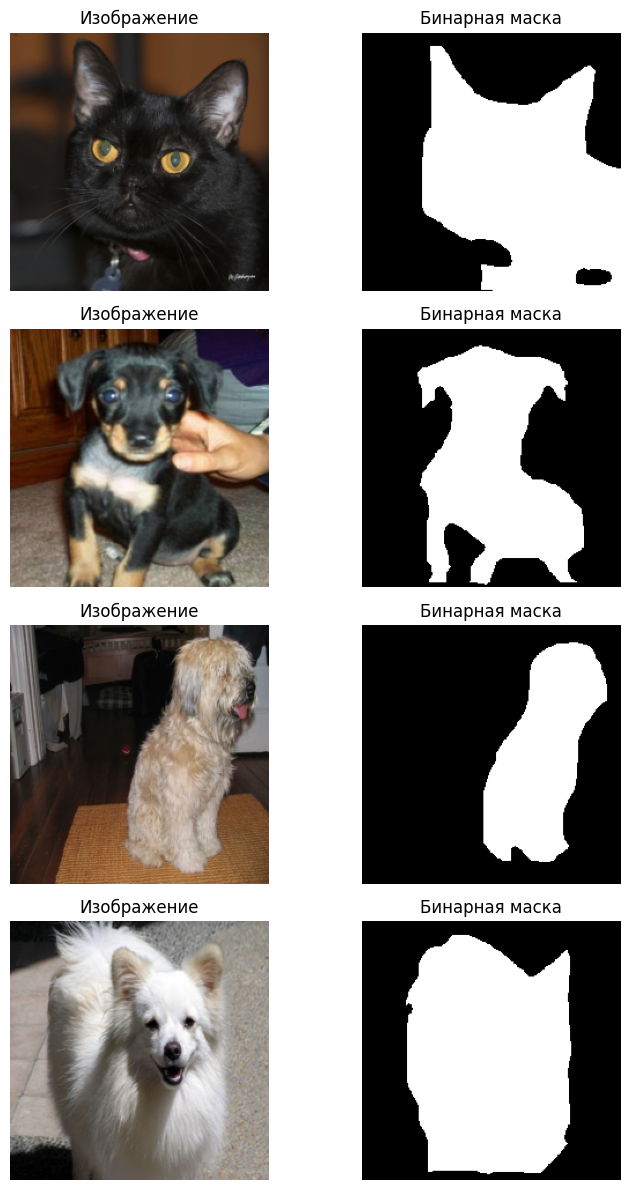

In [42]:
show_segmentation_samples(pet_train_loader, n=4)

## Модель сегментации, постобработка и метрики

In [43]:
seg_weights = models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = models.segmentation.deeplabv3_resnet50(weights=seg_weights).to(device)
seg_model.eval()

print("Segmentation model is ready.")

Segmentation model is ready.


In [44]:
def postprocess_v1(logits):
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)
    binary = (pred != 0).long()
    return binary


def postprocess_v2(logits, threshold=0.7):
    probs = torch.softmax(logits, dim=1)
    foreground_score = 1.0 - probs[:, 0]
    binary = (foreground_score >= threshold).long()
    return binary

In [45]:
def compute_binary_segmentation_metrics(pred_mask, true_mask):
    pred_mask = pred_mask.bool()
    true_mask = true_mask.bool()

    tp = (pred_mask & true_mask).sum().item()
    fp = (pred_mask & ~true_mask).sum().item()
    fn = (~pred_mask & true_mask).sum().item()

    union = (pred_mask | true_mask).sum().item()
    iou = tp / union if union > 0 else 1.0

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return precision, recall, iou

In [46]:
@torch.no_grad()
def evaluate_segmentation(model, loader, device, mode="v1"):
    model.eval()

    precisions = []
    recalls = []
    ious = []

    for images, true_masks in loader:
        images = images.to(device)
        true_masks = true_masks.to(device)

        outputs = model(images)["out"]

        if mode == "v1":
            pred_masks = postprocess_v1(outputs)
        else:
            pred_masks = postprocess_v2(outputs, threshold=0.7)

        for pred_mask, true_mask in zip(pred_masks, true_masks):
            precision, recall, iou = compute_binary_segmentation_metrics(pred_mask, true_mask)
            precisions.append(precision)
            recalls.append(recall)
            ious.append(iou)

    return {
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
        "mean_iou": float(np.mean(ious)),
    }

## Эксперименты V1-V2

In [47]:
metrics_v1 = evaluate_segmentation(seg_model, pet_val_loader, device, mode="v1")
metrics_v2 = evaluate_segmentation(seg_model, pet_val_loader, device, mode="v2")

print("V1:", metrics_v1)
print("V2:", metrics_v2)

V1: {'precision': 0.7017007276167897, 'recall': 0.8877938148554003, 'mean_iou': 0.6499502803060592}
V2: {'precision': 0.7432228117723146, 'recall': 0.8441919844750061, 'mean_iou': 0.667989800384972}


In [48]:
runs.append({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 pretrained",
    "optimizer": None,
    "lr": None,
    "epochs_trained": 0,
    "best_val_accuracy": None,
    "test_accuracy": None,
    "precision": metrics_v1["precision"],
    "recall": metrics_v1["recall"],
    "mean_iou": metrics_v1["mean_iou"],
    "notes": "basic mask postprocessing"
})

runs.append({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 pretrained",
    "optimizer": None,
    "lr": None,
    "epochs_trained": 0,
    "best_val_accuracy": None,
    "test_accuracy": None,
    "precision": metrics_v2["precision"],
    "recall": metrics_v2["recall"],
    "mean_iou": metrics_v2["mean_iou"],
    "notes": "stricter foreground threshold"
})

In [49]:
seg_results_df = pd.DataFrame([r for r in runs if r["task"] == "segmentation"])
seg_results_df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,V1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,None,None,0,None,None,0.701701,0.887794,0.64995,basic mask postprocessing
1,V2,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,None,None,0,None,None,0.743223,0.844192,0.66799,stricter foreground threshold


In [50]:
segmentation_examples_path = FIGURES_DIR / "segmentation_examples.png"
segmentation_metrics_path = FIGURES_DIR / "segmentation_metrics.png"

## Визуализация предсказаний и сохранение графиков

In [51]:
@torch.no_grad()
def visualize_segmentation_predictions(model, loader, device, n=4, mode="v1"):
    images, true_masks = next(iter(loader))
    images = images.to(device)

    outputs = model(images)["out"]

    if mode == "v1":
        pred_masks = postprocess_v1(outputs).cpu()
    else:
        pred_masks = postprocess_v2(outputs, threshold=0.7).cpu()

    images = images.cpu()
    true_masks = true_masks.cpu()

    fig, axes = plt.subplots(n, 3, figsize=(10, 3 * n))

    for i in range(n):
        axes[i, 0].imshow(images[i].permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Изображение")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(true_masks[i].numpy(), cmap="gray")
        axes[i, 1].set_title("Истинная маска")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_masks[i].numpy(), cmap="gray")
        axes[i, 2].set_title(f"Предсказание ({mode})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    return fig

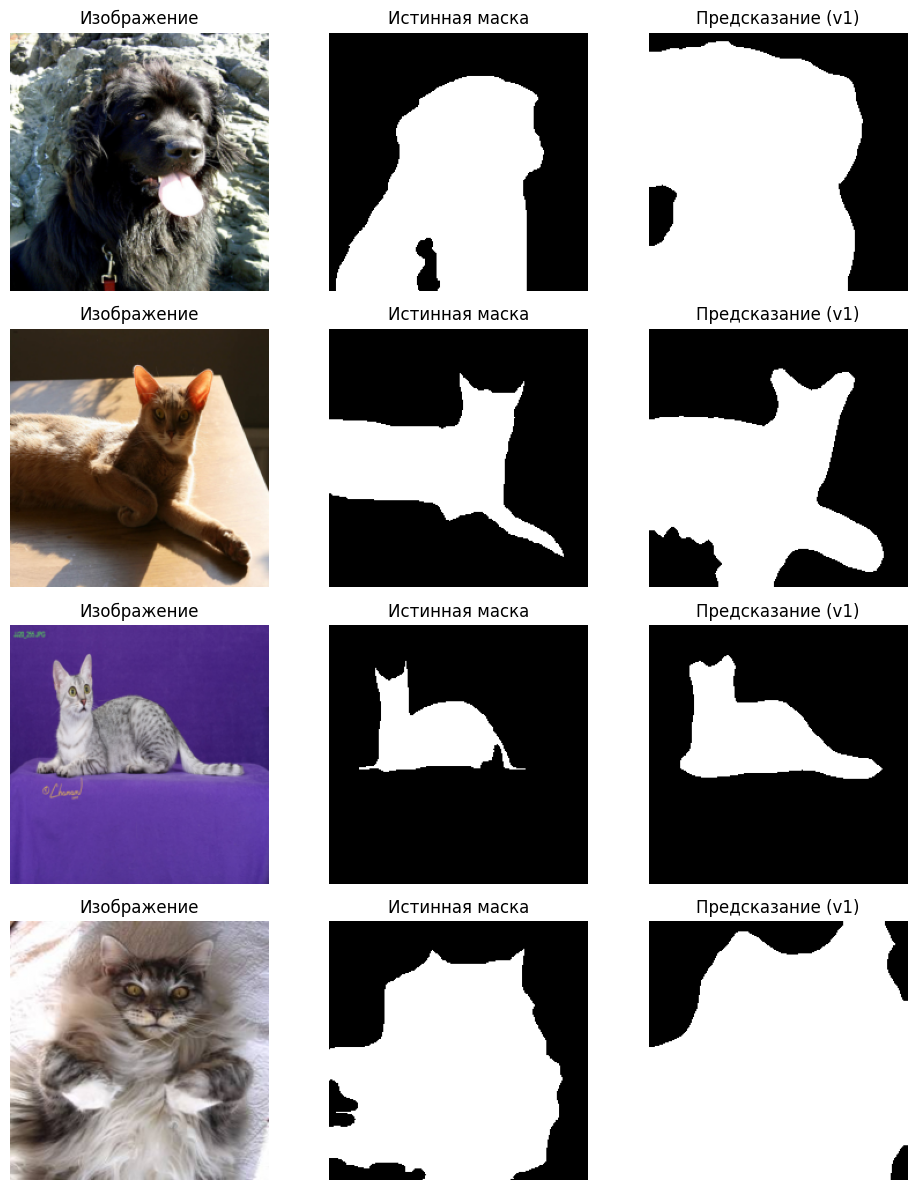

In [52]:
fig = visualize_segmentation_predictions(seg_model, pet_val_loader, device, n=4, mode="v1")
fig.savefig(segmentation_examples_path, dpi=150, bbox_inches="tight")
plt.show()

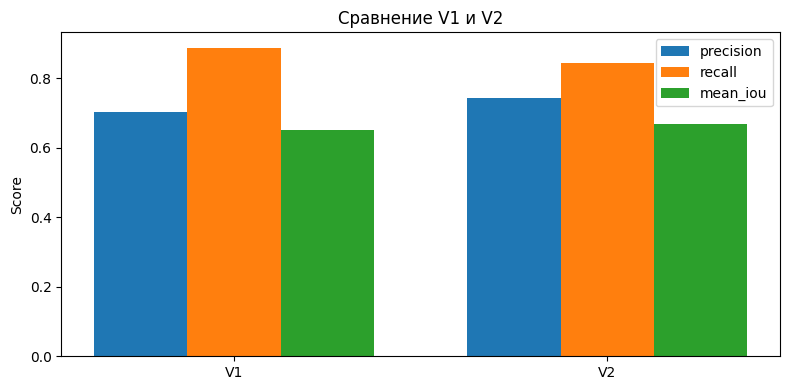

In [53]:
seg_df = pd.DataFrame([
    {"mode": "V1", **metrics_v1},
    {"mode": "V2", **metrics_v2},
])

plt.figure(figsize=(8, 4))
x = np.arange(len(seg_df))
width = 0.25

plt.bar(x - width, seg_df["precision"], width, label="precision")
plt.bar(x, seg_df["recall"], width, label="recall")
plt.bar(x + width, seg_df["mean_iou"], width, label="mean_iou")

plt.xticks(x, seg_df["mode"])
plt.ylabel("Score")
plt.title("Сравнение V1 и V2")
plt.legend()
plt.tight_layout()
plt.savefig(segmentation_metrics_path, dpi=150, bbox_inches="tight")
plt.show()

## Обновление runs.csv и проверка артефактов

In [54]:
runs_df = pd.DataFrame(runs)
runs_df.to_csv(RUNS_CSV_PATH, index=False)
runs_df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN without augmentations,Adam,0.0010,5,0.560,NaN,NaN,NaN,NaN,simple-cnn-base
1,C2,classification,STL10,42,SimpleCNN with augmentations,Adam,0.0010,5,0.501,NaN,NaN,NaN,NaN,simple-cnn-aug
2,C3,classification,STL10,42,"ResNet18 pretrained, head only",Adam,0.0010,5,0.930,NaN,NaN,NaN,NaN,resnet18-head-only
3,C4,classification,STL10,42,"ResNet18 pretrained, layer4 + fc finetune",Adam,0.0001,5,0.946,0.947875,NaN,NaN,NaN,resnet18-finetune
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,None,NaN,0,NaN,NaN,0.701701,0.887794,0.64995,basic mask postprocessing
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,None,NaN,0,NaN,NaN,0.743223,0.844192,0.66799,stricter foreground threshold


In [55]:
print("runs.csv:", RUNS_CSV_PATH.exists())
print("segmentation_examples.png:", segmentation_examples_path.exists())
print("segmentation_metrics.png:", segmentation_metrics_path.exists())

runs.csv: True
segmentation_examples.png: True
segmentation_metrics.png: True
